In [2]:
!pip install seaborn

In [4]:
import seaborn as sns
import pandas as pd
from matplotlib import pyplot as plt

In [5]:
df = pd.read_csv("List of Countries by Sugarcane Production.csv")

In [8]:
df.head()

,Unnamed: 0,Country,Continent,Production (Tons),Production per Person (Kg),Acreage (Hectare),Yield (Kg / Hectare)
0,0,Brazil,South America,768.678.382,"3.668,531",10.226.205,"75.167,5"
1,1,India,Asia,348.448.000,260721,4.950.000,"70.393,5"
2,2,China,Asia,123.059.739,88287,1.675.215,"73.459,1"
3,3,Thailand,Asia,87.468.496,"1.264,303",1.336.575,"65.442,2"
4,4,Pakistan,Asia,65.450.704,324219,1.130.820,57.879


In [10]:
df.shape

(103, 7)

DATA CLEANING

In [13]:
df["Production (Tons)"]=df["Production (Tons)"].str.replace(".",",")
df["Production per Person (Kg)"]=df["Production per Person (Kg)"].str.replace(".","").str.replace(",",".")
df["Acreage (Hectare)"]=df["Acreage (Hectare)"].str.replace(".",",")
df["Yield (Kg / Hectare)"]=df["Yield (Kg / Hectare)"].str.replace(".","").str.replace(",",".")

In [15]:
df.head()

,Unnamed: 0,Country,Continent,Production (Tons),Production per Person (Kg),Acreage (Hectare),Yield (Kg / Hectare)
0,0,Brazil,South America,"768,678,382",3668.531,"10,226,205",75167.5
1,1,India,Asia,"348,448,000",260721,"4,950,000",70393.5
2,2,China,Asia,"123,059,739",88287,"1,675,215",73459.1
3,3,Thailand,Asia,"87,468,496",1264.303,"1,336,575",65442.2
4,4,Pakistan,Asia,"65,450,704",324219,"1,130,820",57879


In [17]:
df.rename(columns={"Production (Tons)":"Production(Tons)"},inplace=True)
df.rename(columns={"Production per Person (Kg)":"Production_per_Person(Kg)"},inplace=True)
df.rename(columns={"Acreage (Hectare)":"Acreage(Hectare)"},inplace=True)
df.rename(columns={"Yield (Kg / Hectare)":"Yield(Kg/Hectare)"},inplace=True)

In [19]:
df.head()

,Unnamed: 0,Country,Continent,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,0,Brazil,South America,"768,678,382",3668.531,"10,226,205",75167.5
1,1,India,Asia,"348,448,000",260721,"4,950,000",70393.5
2,2,China,Asia,"123,059,739",88287,"1,675,215",73459.1
3,3,Thailand,Asia,"87,468,496",1264.303,"1,336,575",65442.2
4,4,Pakistan,Asia,"65,450,704",324219,"1,130,820",57879


In [21]:
df.isna().sum()

Unnamed: 0                   0
Country                      0
Continent                    0
Production(Tons)             0
Production_per_Person(Kg)    0
Acreage(Hectare)             1
Yield(Kg/Hectare)            1
dtype: int64

In [23]:
df[df["Acreage(Hectare)"].isna()]

,Unnamed: 0,Country,Continent,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
99,99,Djibouti,Africa,53,51,NaN,NaN


In [25]:
df=df.dropna().reset_index()

In [27]:
# Drop rows with any missing values (NaN) and reset the index to have a clean, sequential index
df = df.dropna().reset_index()

In [29]:
df.isna().sum()

level_0                      0
index                        0
Unnamed: 0                   0
Country                      0
Continent                    0
Production(Tons)             0
Production_per_Person(Kg)    0
Acreage(Hectare)             0
Yield(Kg/Hectare)            0
dtype: int64

In [31]:
# Check the number of missing values in each column of the dataframe
# This returns a Series with column names as index and count of NaN values as values
df.isna().sum()

level_0                      0
index                        0
Unnamed: 0                   0
Country                      0
Continent                    0
Production(Tons)             0
Production_per_Person(Kg)    0
Acreage(Hectare)             0
Yield(Kg/Hectare)            0
dtype: int64

In [33]:
df.drop(["index","Unnamed: 0"],axis=1,inplace=True)

In [35]:
df.head()


,level_0,Country,Continent,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,0,Brazil,South America,"768,678,382",3668.531,"10,226,205",75167.5
1,1,India,Asia,"348,448,000",260721,"4,950,000",70393.5
2,2,China,Asia,"123,059,739",88287,"1,675,215",73459.1
3,3,Thailand,Asia,"87,468,496",1264.303,"1,336,575",65442.2
4,4,Pakistan,Asia,"65,450,704",324219,"1,130,820",57879


In [37]:
df.drop("level_0",axis=1,inplace=True)

In [39]:
df.head()

,Country,Continent,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,Brazil,South America,"768,678,382",3668.531,"10,226,205",75167.5
1,India,Asia,"348,448,000",260721,"4,950,000",70393.5
2,China,Asia,"123,059,739",88287,"1,675,215",73459.1
3,Thailand,Asia,"87,468,496",1264.303,"1,336,575",65442.2
4,Pakistan,Asia,"65,450,704",324219,"1,130,820",57879


In [41]:
df.dtypes

Country                      object
Continent                    object
Production(Tons)             object
Production_per_Person(Kg)    object
Acreage(Hectare)             object
Yield(Kg/Hectare)            object
dtype: object

CONVERTING THE DATA TYPE

In [44]:
df["Production(Tons)"] = df["Production(Tons)"].astype(str).str.replace(',', '', regex=True).astype(float)
df["Acreage(Hectare)"] = df["Acreage(Hectare)"].astype(str).str.replace(',', '', regex=True).astype(float)
df["Production_per_Person(Kg)"] = df["Production_per_Person(Kg)"].astype(str).str.replace(',', '', regex=True).astype(float)
df["Yield(Kg/Hectare)"] = df["Yield(Kg/Hectare)"].astype(str).str.replace(',', '', regex=True).astype(float)

In [46]:
df.head()

,Country,Continent,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,Brazil,South America,768678382.0,3668.531,10226205.0,75167.5
1,India,Asia,348448000.0,260721.000,4950000.0,70393.5
2,China,Asia,123059739.0,88287.000,1675215.0,73459.1
3,Thailand,Asia,87468496.0,1264.303,1336575.0,65442.2
4,Pakistan,Asia,65450704.0,324219.000,1130820.0,57879.0


In [48]:
df.dtypes

Country                       object
Continent                     object
Production(Tons)             float64
Production_per_Person(Kg)    float64
Acreage(Hectare)             float64
Yield(Kg/Hectare)            float64
dtype: object

In [50]:
df.nunique()


Country                      102
Continent                      6
Production(Tons)             102
Production_per_Person(Kg)    101
Acreage(Hectare)             101
Yield(Kg/Hectare)            102
dtype: int64

In [52]:
df.head()


,Country,Continent,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,Brazil,South America,768678382.0,3668.531,10226205.0,75167.5
1,India,Asia,348448000.0,260721.000,4950000.0,70393.5
2,China,Asia,123059739.0,88287.000,1675215.0,73459.1
3,Thailand,Asia,87468496.0,1264.303,1336575.0,65442.2
4,Pakistan,Asia,65450704.0,324219.000,1130820.0,57879.0


<Axes: xlabel='Continent'>

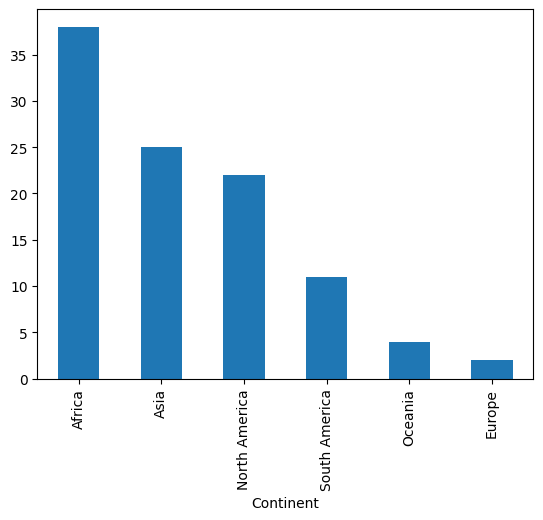

In [54]:
df["Continent"].value_counts().plot(kind="bar")

C:\Users\Rahhul\AppData\Local\Temp\ipykernel_17152\3389213774.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Production(Tons)"])
C:\Users\Rahhul\AppData\Local\Temp\ipykernel_17152\3389213774.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Production_per_Person(Kg)"])
C:\Users\Ra

<Axes: xlabel='Yield(Kg/Hectare)', ylabel='Density'>

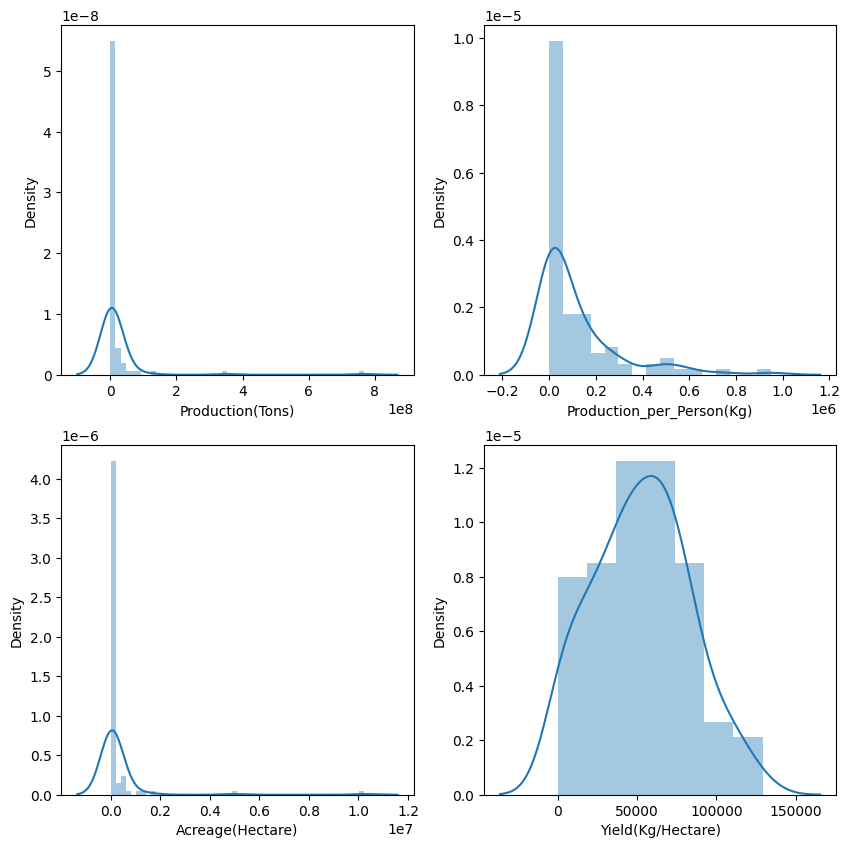

In [56]:
plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
sns.distplot(df["Production(Tons)"])
plt.subplot(2,2,2)
sns.distplot(df["Production_per_Person(Kg)"])
plt.subplot(2,2,3)
sns.distplot(df["Acreage(Hectare)"])
plt.subplot(2,2,4)
sns.distplot(df["Yield(Kg/Hectare)"])

<Axes: ylabel='Yield(Kg/Hectare)'>

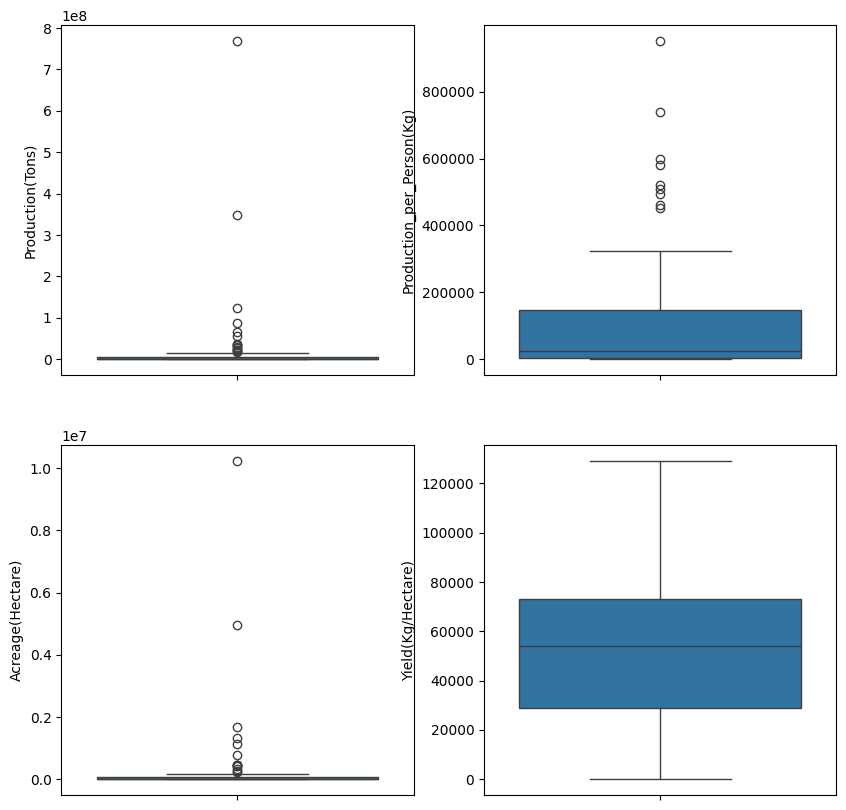

In [58]:
 plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
sns.boxplot(df["Production(Tons)"])
plt.subplot(2,2,2)
sns.boxplot(df["Production_per_Person(Kg)"])
plt.subplot(2,2,3)
sns.boxplot(df["Acreage(Hectare)"])
plt.subplot(2,2,4)
sns.boxplot(df["Yield(Kg/Hectare)"])

In [60]:
df.describe()

,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
count,1.020000e+02,102.000000,1.020000e+02,102.000000
mean,1.850372e+07,112952.435755,2.498981e+05,52628.078431
std,8.419149e+07,176651.341929,1.137003e+06,30504.676683
min,1.000000e+00,0.000000,0.000000e+00,10.000000
25%,6.251875e+04,3671.910000,1.104000e+03,29072.025000
50%,1.440044e+06,25572.500000,1.655800e+04,54108.950000
75%,6.426824e+06,146384.750000,8.047400e+04,73282.700000
max,7.686784e+08,951087.000000,1.022620e+07,129049.300000


In [62]:
df_new=df[["Country","Production(Tons)"]].set_index("Country")
df_new

,Production(Tons)
Country,
Brazil,768678382.0
India,348448000.0
China,123059739.0
Thailand,87468496.0
Pakistan,65450704.0
...,...
Spain,394.0
Lebanon,97.0
Singapore,50.0


In [64]:
df_new["Production(Tons)_percent"]=df_new["Production(Tons)"]*100/df_new["Production(Tons)"].sum()

In [66]:
df_new.dtypes

Production(Tons)            float64
Production(Tons)_percent    float64
dtype: object

In [68]:
df_new

,Production(Tons),Production(Tons)_percent
Country,,
Brazil,768678382.0,4.072729e+01
India,348448000.0,1.846200e+01
China,123059739.0,6.520138e+00
Thailand,87468496.0,4.634389e+00
Pakistan,65450704.0,3.467809e+00
...,...,...
Spain,394.0,2.087551e-05
Lebanon,97.0,5.139401e-06
Singapore,50.0,2.649176e-06


<Axes: ylabel='Production(Tons)_percent'>

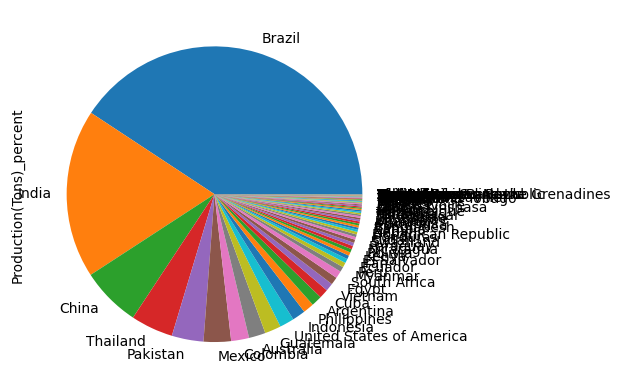

In [70]:
df_new["Production(Tons)_percent"].plot(kind="pie")

<Axes: xlabel='Country'>

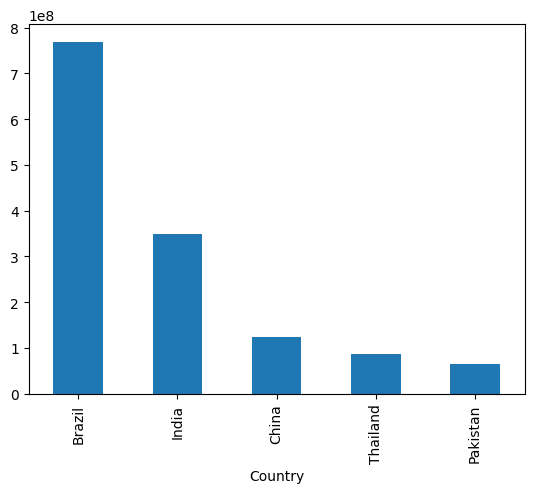

In [71]:
df_new["Production(Tons)"].head().plot(kind="bar")

C:\Users\Rahhul\AppData\Local\Temp\ipykernel_17152\3578709949.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


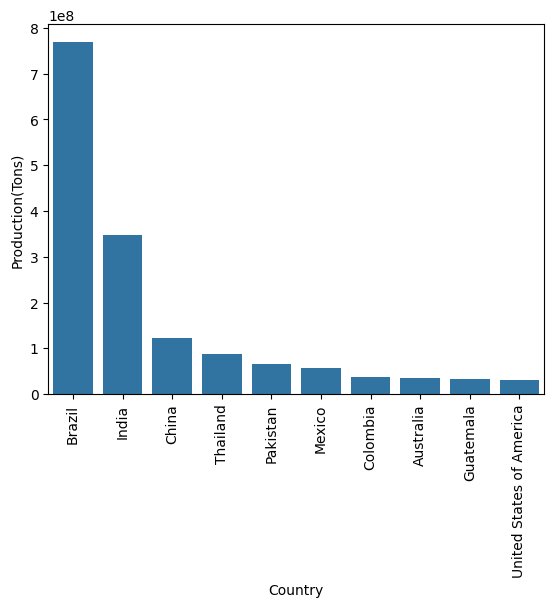

In [74]:
ax=sns.barplot(data=df.head(10),x="Country",y="Production(Tons)")
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)
plt.show()

C:\Users\Rahhul\AppData\Local\Temp\ipykernel_17152\1053118958.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


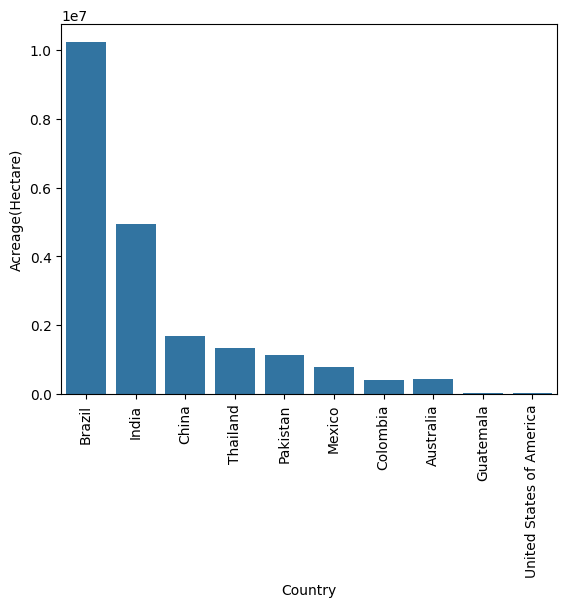

In [76]:
ax=sns.barplot(data=df.head(10),x="Country",y="Acreage(Hectare)")
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)
plt.show()

In [78]:
df.head()

,Country,Continent,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,Brazil,South America,768678382.0,3668.531,10226205.0,75167.5
1,India,Asia,348448000.0,260721.000,4950000.0,70393.5
2,China,Asia,123059739.0,88287.000,1675215.0,73459.1
3,Thailand,Asia,87468496.0,1264.303,1336575.0,65442.2
4,Pakistan,Asia,65450704.0,324219.000,1130820.0,57879.0


C:\Users\Rahhul\AppData\Local\Temp\ipykernel_17152\2240262550.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


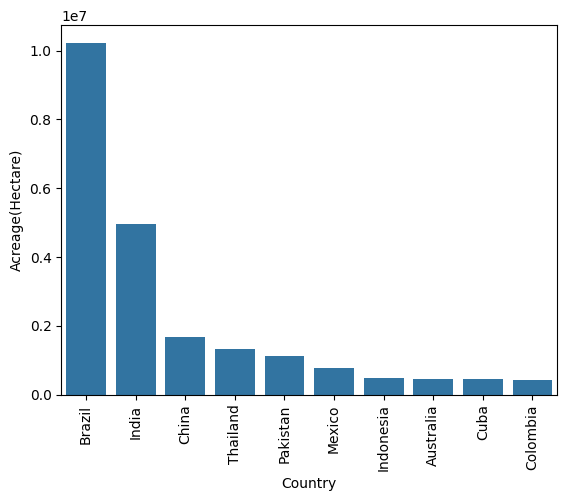

In [80]:
df_acr=df.sort_values("Acreage(Hectare)",ascending=False)
ax=sns.barplot(data=df_acr.head(10),x="Country",y="Acreage(Hectare)")
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)
plt.show()


In [82]:
df.head()

,Country,Continent,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,Brazil,South America,768678382.0,3668.531,10226205.0,75167.5
1,India,Asia,348448000.0,260721.000,4950000.0,70393.5
2,China,Asia,123059739.0,88287.000,1675215.0,73459.1
3,Thailand,Asia,87468496.0,1264.303,1336575.0,65442.2
4,Pakistan,Asia,65450704.0,324219.000,1130820.0,57879.0


C:\Users\Rahhul\AppData\Local\Temp\ipykernel_17152\2938358024.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


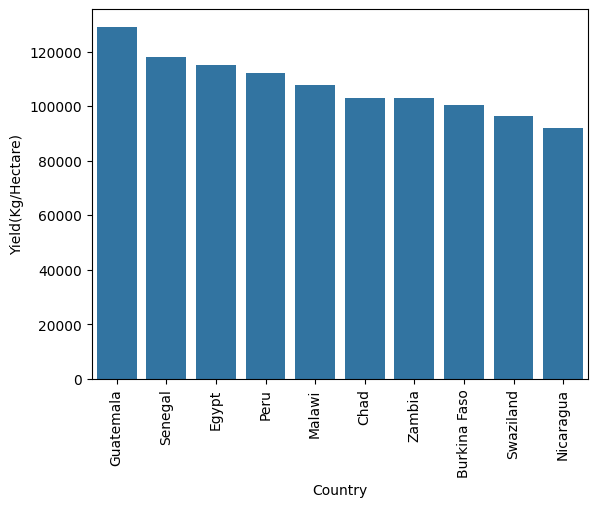

In [84]:
df_y=df.sort_values("Yield(Kg/Hectare)",ascending=False)
ax=sns.barplot(data=df_y.head(10),x="Country",y="Yield(Kg/Hectare)")
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)
plt.show()

C:\Users\Rahhul\AppData\Local\Temp\ipykernel_17152\198625678.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=90)


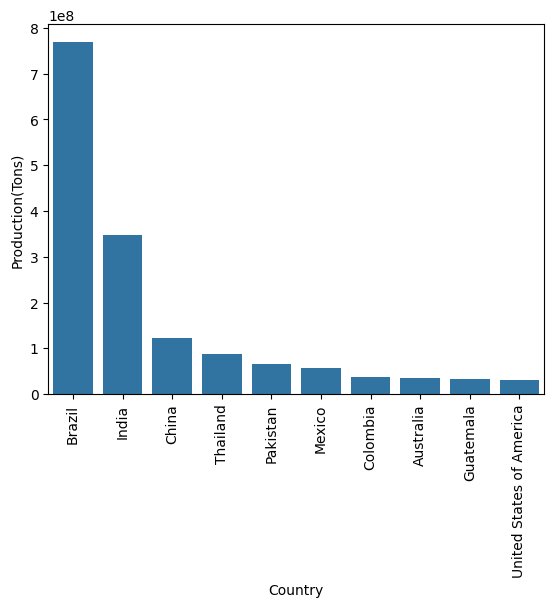

In [86]:
df_p=df.sort_values("Production(Tons)",ascending=False)
ax=sns.barplot(data=df_p.head(10),x="Country",y="Production(Tons)")
ax.set_xticklabels(ax.get_xticklabels(),rotation=90)
plt.show()


In [88]:
df.corr()

ValueError: could not convert string to float: 'Brazil'

In [90]:
# Create a new DataFrame containing only the numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Now, calculate the correlation
correlation_matrix = numeric_df.corr()
print(correlation_matrix)

                           Production(Tons)  Production_per_Person(Kg)  \
Production(Tons)                   1.000000                   0.015000   
Production_per_Person(Kg)          0.015000                   1.000000   
Acreage(Hectare)                   0.997550                   0.012557   
Yield(Kg/Hectare)                  0.132812                   0.017999   

                           Acreage(Hectare)  Yield(Kg/Hectare)  
Production(Tons)                   0.997550           0.132812  
Production_per_Person(Kg)          0.012557           0.017999  
Acreage(Hectare)                   1.000000           0.113433  
Yield(Kg/Hectare)                  0.113433           1.000000  


<Axes: >

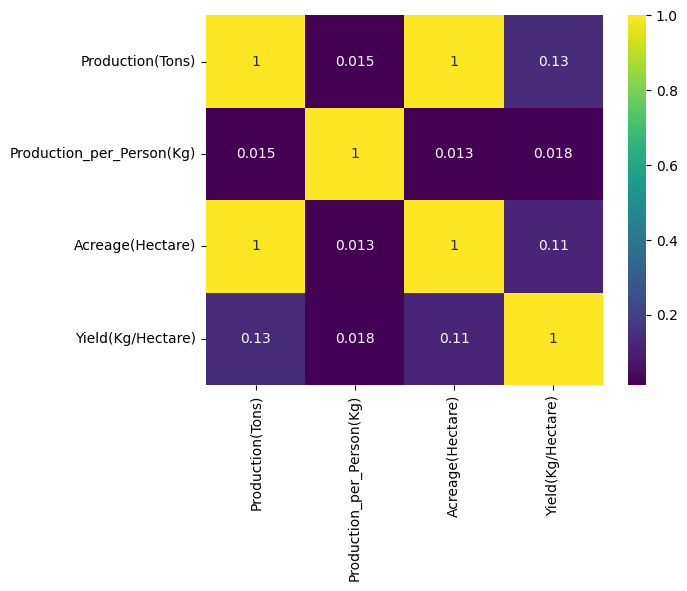

In [149]:
sns.heatmap(numeric_df.corr(),annot=True ,cmap="viridis")

<Axes: xlabel='Acreage(Hectare)', ylabel='Production(Tons)'>

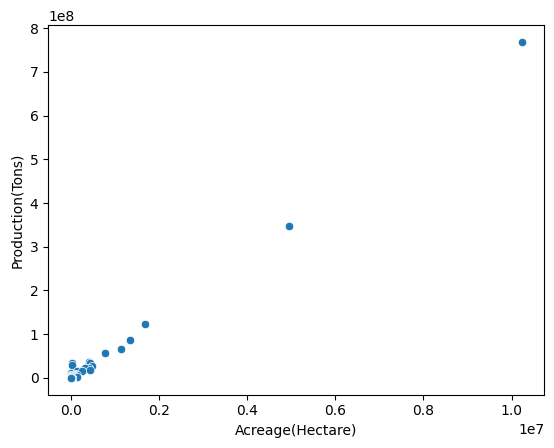

In [92]:
sns.scatterplot(data=df,x="Acreage(Hectare)",y="Production(Tons)")

<Axes: xlabel='Yield(Kg/Hectare)', ylabel='Production(Tons)'>

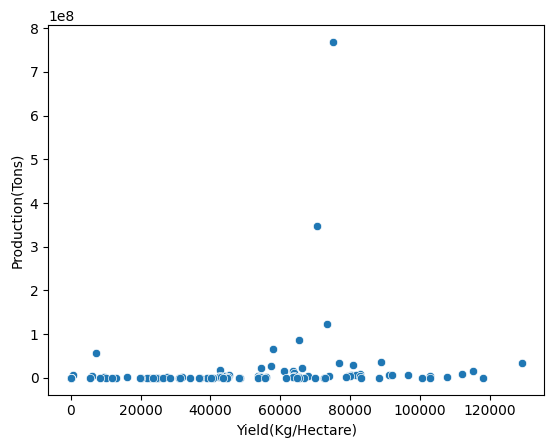

In [94]:
sns.scatterplot(data=df,x="Yield(Kg/Hectare)",y="Production(Tons)")

In [96]:
df_co=df.groupby("Continent").sum()

In [98]:
df_co

,Country,Production(Tons),Production_per_Person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
Continent,,,,,
Africa,EgyptSouth AfricaKenyaSwazilandSudanZambiaMaur...,89681472.0,2332636.293,1439089.0,2142107.5
Asia,IndiaChinaThailandPakistanIndonesiaPhilippines...,721930425.0,1857769.303,10608319.0,1171871.4
Europe,PortugalSpain,5823.0,536.000,71.0,131870.9
North America,MexicoGuatemalaUnited States of AmericaCubaEl ...,173995947.0,3796081.508,1581983.0,1082602.4
Oceania,AustraliaFijiPapua New GuineaSamoa,36177574.0,28593.605,490909.0,162419.1
South America,BrazilColombiaArgentinaPeruEcuadorBoliviaParag...,865588126.0,3505531.738,11369236.0,677192.7


<Axes: xlabel='Continent'>

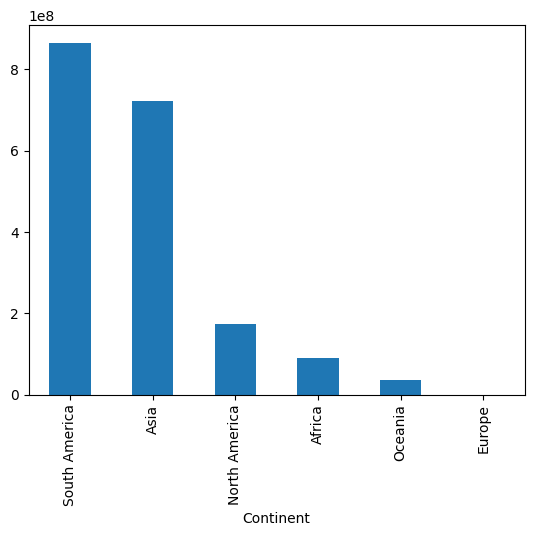

In [100]:
df_co["Production(Tons)"].sort_values(ascending=False).plot(kind="bar")


In [102]:
df["Continent"].value_counts()

Continent
Africa           38
Asia             25
North America    22
South America    11
Oceania           4
Europe            2
Name: count, dtype: int64

<Axes: xlabel='Continent'>

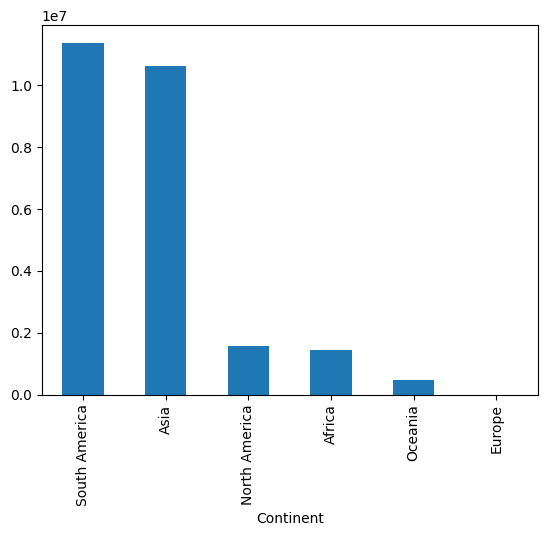

In [167]:
 df_co["Acreage(Hectare)"].sort_values(ascending=False).plot(kind="bar")

<Axes: ylabel='Production(Tons)'>

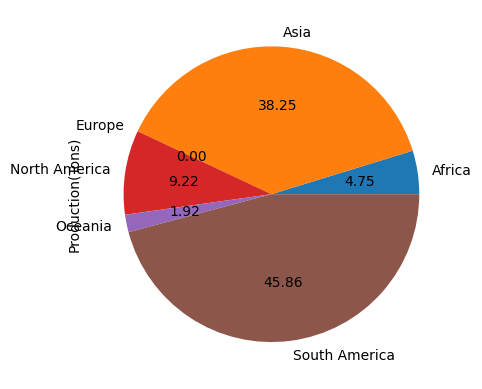

In [106]:
df_co["Production(Tons)"].plot(kind="pie",autopct="%.2f")